In [14]:
# We import the necessary libraries for our neural network training.
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

Shapes: torch.Size([9]) torch.Size([9])


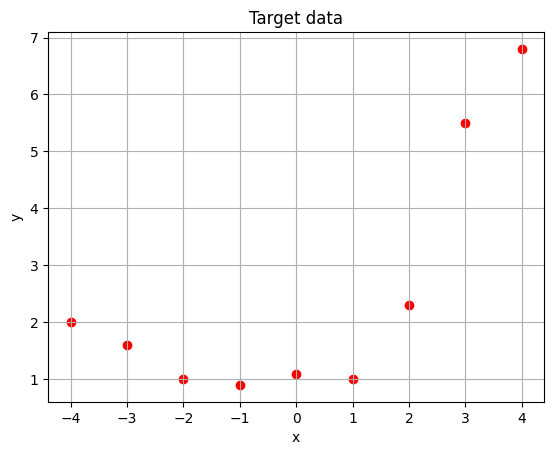

In [15]:
# The data is the same as in the previous notebook.
x_target = torch.tensor([-4.0, -3, -2, -1, 0, 1, 2, 3, 4])
y_target = torch.tensor([2, 1.6, 1.0, 0.9, 1.1, 1.0, 2.3, 5.5, 6.8])
print("Shapes:", x_target.shape, y_target.shape)

plt.scatter(x_target, y_target, color="red")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
t = plt.title("Target data")

In [16]:
# For training, we need to reshape the data to have a shape of (N, 1), where N is the number of samples.
# This is needed because the neural network expects single feature input and single target output.
x_target = x_target.view(-1, 1)
y_target = y_target.view(-1, 1)
print("Shapes:", x_target.shape, y_target.shape)

Shapes: torch.Size([9, 1]) torch.Size([9, 1])


In [17]:
# As in the previous notebook, we define a feedforward neural network with one hidden layer and ReLU activation function.
torch.manual_seed(1234) # We set a random seed for reproducibility.
linear_layer_1 = nn.Linear(in_features=1, out_features=2)
activation_function = nn.ReLU()
linear_layer_2 = nn.Linear(in_features=2, out_features=1)
fcn = nn.Sequential(linear_layer_1, activation_function, linear_layer_2)
print("Feedforward neural network:", fcn)

Feedforward neural network: Sequential(
  (0): Linear(in_features=1, out_features=2, bias=True)
  (1): ReLU()
  (2): Linear(in_features=2, out_features=1, bias=True)
)


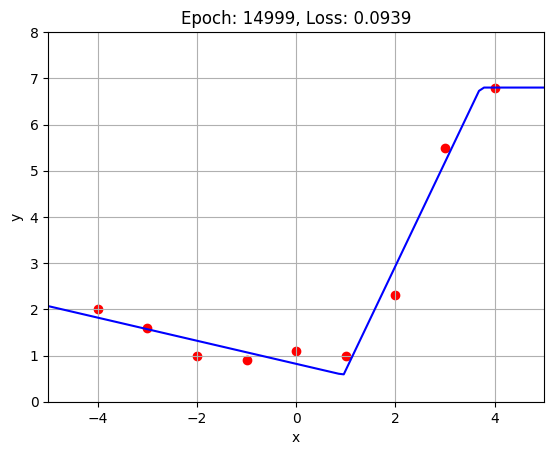

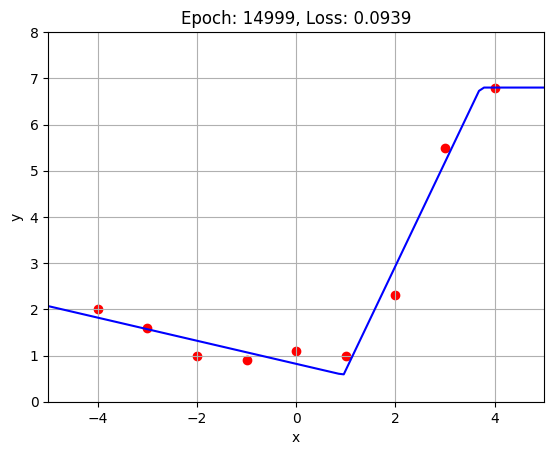

In [18]:
import torch.optim as optim # Optimizers are used to update the parameters of the neural network based on the computed gradients.
from interactive_plot import plot_prediction

# We use the Adam optimizer, which is a popular choice for training neural networks. 
# We pass the parameters of the neural network and set a learning rate of 0.001 (the step size for the gradient descent).
optimizer = optim.Adam(fcn.parameters(), lr=0.001)

fig, axis = plt.subplots() # this is for plotting the predictions during training.

num_epochs = 15000 # Number of training iterations = number of gradient descent steps.
for epoch in range(num_epochs):
    optimizer.zero_grad() # We need to zero the gradients before computing the new gradients for the current iteration.
    
    # Evaluate the neural network on the input data to get the predictions. 
    # Then we compute the mean squared error loss between the predictions and the target values.
    y_pred = fcn(x_target)
    loss = torch.mean((y_pred - y_target) ** 2)
    
    # Backward pass: we compute the gradients of the loss with respect to the parameters of the neural network.
    loss.backward()
    # Update the parameters of the neural network using the computed gradients and the optimizer.
    optimizer.step()

    # Every few epochs, we plot the predictions of the neural network to visualize the training progress.
    if epoch % 1000 == 0 or epoch == num_epochs - 1:
        plot_prediction(fig, axis, epoch, loss, fcn)

In [19]:
# We can also check out what values the parameters of the neural network have after training.
for param in fcn.parameters():
    print(param.data)

tensor([[-0.6847],
        [-1.2095]])
tensor([2.5460, 1.1546])
tensor([[-3.2862,  2.0670]])
tensor([6.8000])


### Exercise: Training a Neural Network

Modify the above code to try out different setups:
1. Increase the number of neurons in the hidden layer and train again, what do you observe?
2. Switch the learning rate of the optimizer first to 0.1 and then to 0.0001 and train again, what do you observe?
3. Switch the optimizer to `torch.optim.SGD` with learning rate 0.001 and train again, what do you observe?